In [1]:
from google.colab import files
uploaded = files.upload()


Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Titanic-Dataset.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df.describe(include="object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


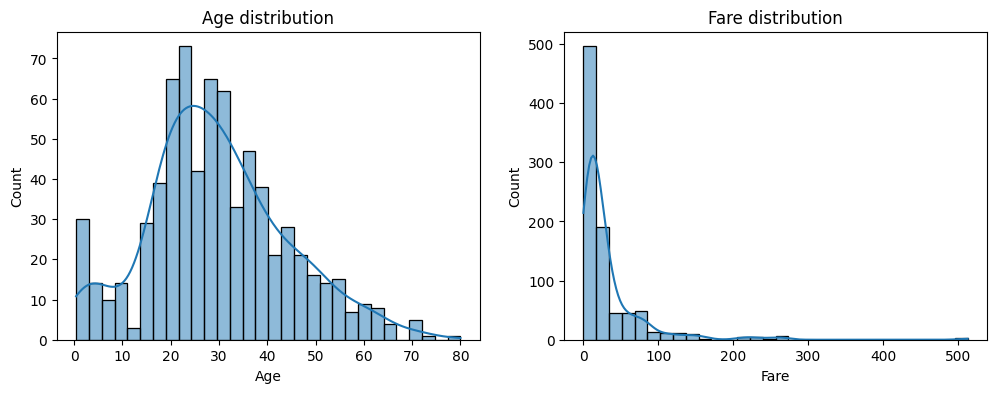

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["Age"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Age distribution")

sns.histplot(df["Fare"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Fare distribution")

plt.savefig("histograms.png")
plt.show()

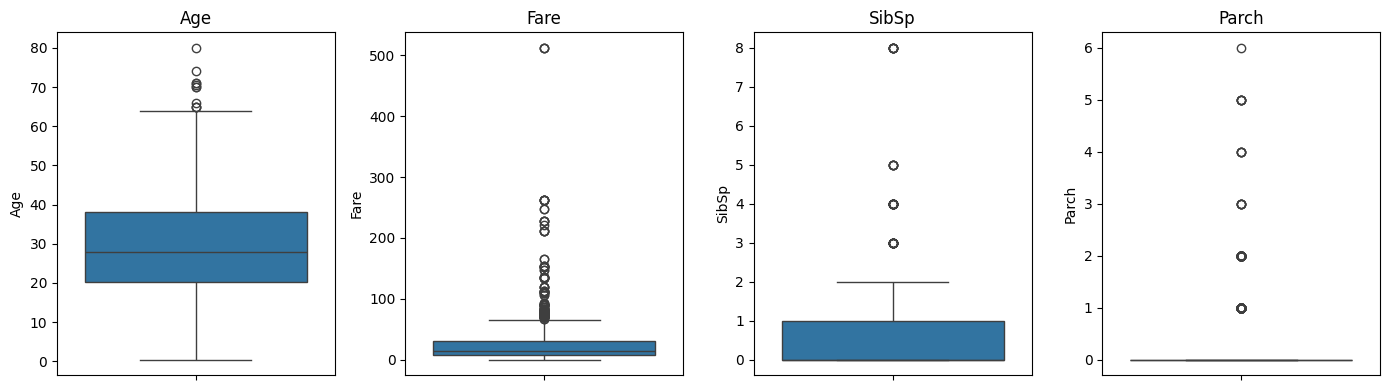

In [6]:
cols = ["Age", "Fare", "SibSp", "Parch"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, col in zip(axes, cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.savefig("boxplots.png")
plt.show()

In [7]:
for col in ["Age", "Fare", "SibSp", "Parch"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(col, n)

Age 11
Fare 116
SibSp 46
Parch 213


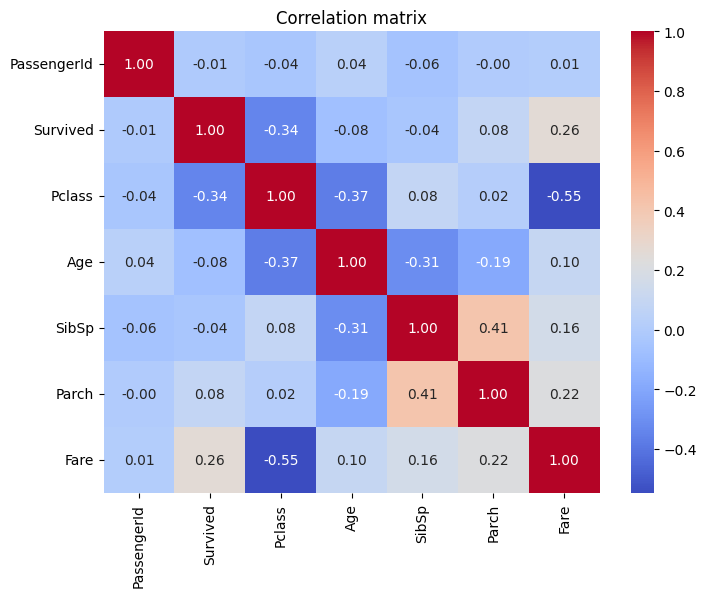

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.savefig("correlation_heatmap.png")
plt.show()


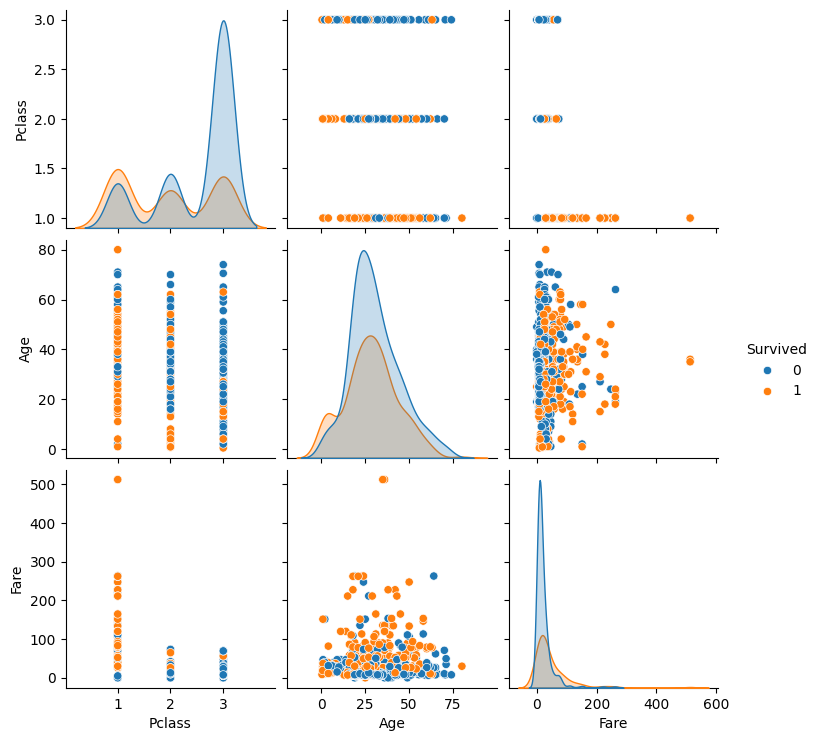

In [9]:
sns.pairplot(df[["Survived", "Pclass", "Age", "Fare"]], hue="Survived")
plt.savefig("pairplot.png")
plt.show()


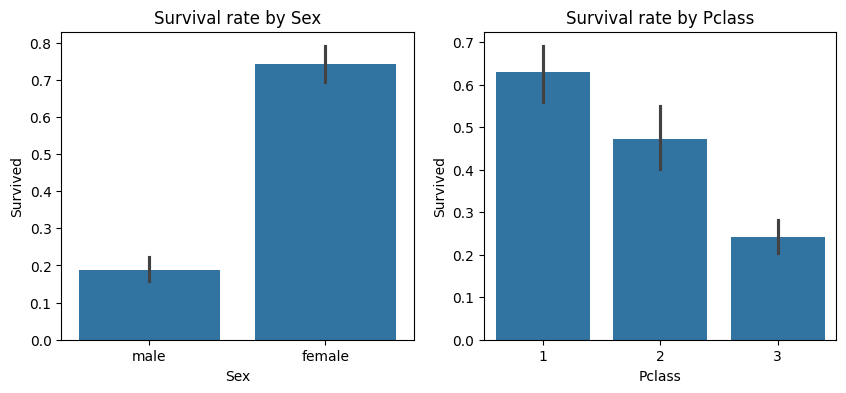

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(x="Sex", y="Survived", data=df, ax=axes[0])
axes[0].set_title("Survival rate by Sex")

sns.barplot(x="Pclass", y="Survived", data=df, ax=axes[1])
axes[1].set_title("Survival rate by Pclass")

plt.savefig("survival_patterns.png")
plt.show()

In [11]:
import plotly.express as px

fig = px.histogram(df, x="Age", color="Survived", nbins=30,
                   title="Age and Survival")
fig.show()

In [12]:
from google.colab import files
files.download("histograms.png")
files.download("boxplots.png")
files.download("correlation_heatmap.png")
files.download("pairplot.png")
files.download("survival_patterns.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>